# Exercise 5 — Neural Networks

In this exercise, you will understand how a neural network learns by:

* combining inputs with weights
* applying activation functions
* training over epochs
* evaluating performance

## Part A — From Neuron to Prediction

A neuron receives inputs, combines them, and produces an output. `inputs → weighted sum → activation → output`

Mathematically `z = w1*x1 + w2*x2 + b`

Then `output = activation(z)`

In [2]:
import numpy as np

import matplotlib.pyplot as plt

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x1 = 2
x2 = 3

w1 = 0.8
w2 = -2
b = 3

z = w1*x1 + w2*x2 + b
output = sigmoid(z)

print("z =", z)
print("output =", output)

z = -1.4000000000000004
output = 0.1978161114414182


### Questions

1. What happens if you change w1?
2. What happens if you change w2?
3. What happens if you change b?
4. Why do we need an activation function?

1. w1 controls input x1 contributes to the weighted sum z. Increase w1 - z rises - sigmoid
output moves toward 1. Decrease or negative w1 - z falls - output moves toward 0.
2. Change w2 is the same as w1 but for x2. Currently negative, so x2 is dragging z down.
3. Change b - Shifts z up or down regardless of inputs. It's the neuron's baseline firing threshold.
4. We need to activate it because without activating, stacking layers is just linear math.
Activation adds non-linearity so the network can learn complex patterns.
1. Its formula 1/(1 + np.exp(-x)) always produces values strictly
between 0 and 1, no matter how large or small the input is.
2. ReLU. It does max(0, x) — if x is positive, it stays exactly
the same; if x is negative, it becomes 0.
3. Tanh. It works like sigmoid but is centered at 0, so it ranges
from -1 to +1 instead of 0 to 1.
4. Sigmoid. Because it outputs a value between 0 and 1, so we can
treat it directly as a probability.

1. Changing w1
   Increasing w1 increases the output, while decreasing w1 lowers the output.

2. Changing w2
   Increasing w2 increases the output, while decreasing w2 lowers the output.

3. Changing b
   Changing the bias b shifts the output up or down similarly to the weights.

4. Why use an activation function?
   Activation functions add non-linearity, allowing neural networks to learn complex patterns instead of behaving like a simple linear model.


## Part B — Activation Functions

In [4]:
x = np.linspace(-5, 5, 200)

print("mean:", np.mean(x))
print("std:", np.std(x))
print("variance:", np.var(x))
print("min:", np.min(x))
print("max:", np.max(x))
print("median:", np.median(x))
print("sum:", np.sum(x))

mean: 1.4210854715202004e-16
std: 2.901221368171633
variance: 8.41708542713568
min: -5.0
max: 5.0
median: 4.440892098500626e-16
sum: 2.842170943040401e-14


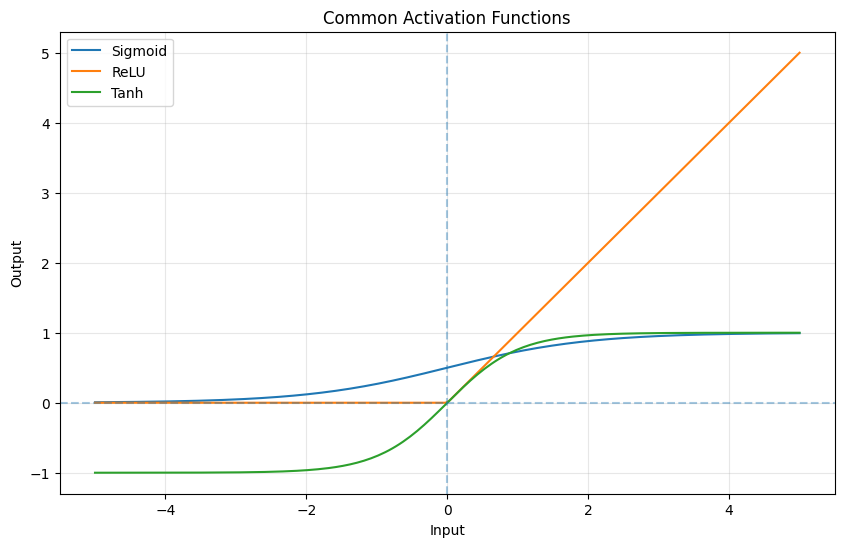

In [5]:
sigmoid_y = 1 / (1 + np.exp(-x))
relu_y = np.maximum(0, x)
tanh_y = np.tanh(x)

plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid_y, label="Sigmoid")
plt.plot(x, relu_y, label="ReLU")
plt.plot(x, tanh_y, label="Tanh")

plt.axhline(0, linestyle="--", alpha=0.4)
plt.axvline(0, linestyle="--", alpha=0.4)

plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Questions

1. Which activation outputs values between 0 and 1? Sigmoid funtion
2. Which activation keeps positive values unchanged? ReLU
3. Which activation outputs values between -1 and 1? Tanh
4. Which activation would you use for binary classification? I would use Sigmoid funtion as values are between 0 and 1

## Part C — Build a Small Neural Network

We will train a neural network to classify two groups of points.

### Step 1 — Create a Dataset

In [6]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train[:10]

array([[ 0.47898636,  0.96035301],
       [ 2.18078733, -0.15299144],
       [ 1.82978889,  0.17962848],
       [ 0.41314607, -0.29959381],
       [ 1.11157234,  0.28406058],
       [ 0.82466792, -0.03605856],
       [ 0.31021356,  0.82738846],
       [-0.97910539,  0.39922287],
       [-0.69797603,  0.66254685],
       [ 0.10072044,  1.27917835]])

In [7]:
y_train[:10]

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 0])

Look at the data.
* What type of ML problem is this?  This is a binary classification problem because output is either 0 or 1
* How many features does the dataset have? There are 2

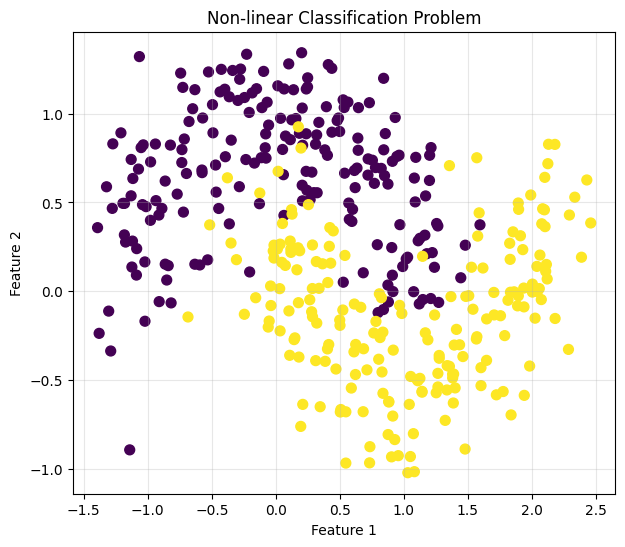

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.title("Non-linear Classification Problem")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

### Why this dataset?

This dataset cannot be easily separated by a straight line.

A neural network can learn a non-linear decision boundary.

Other simulated datasets [here](https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators).

## Part D — Train a Neural Network

Check the documentation for [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8083333333333333


## Part E — Visualize the Decision Boundary

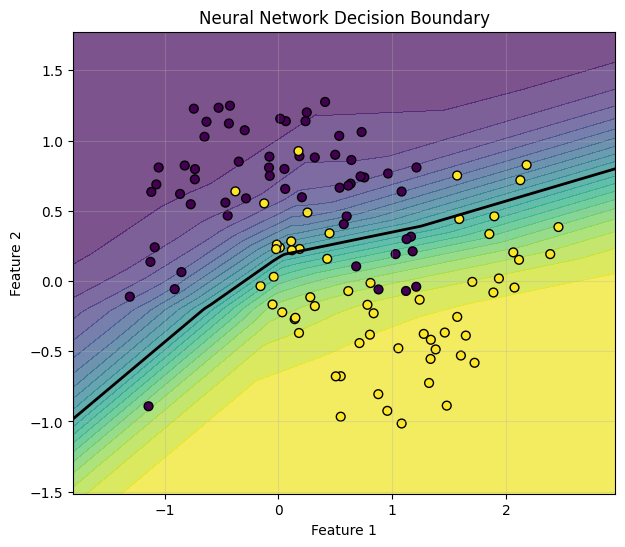

In [11]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1]
    probs = probs.reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    # probability background
    plt.contourf(xx, yy, probs, levels=20, alpha=0.7)

    # decision boundary: probability = 0.5
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    # data points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor="k")

    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(model, X_test, y_test)

### Questions

1. Is the decision boundary linear or non-linear? This is a straight line so non-linear
2. Does the model separate the two classes well? Quite well but there are still 20% mistakes
3. Where does it make mistakes? Around (0, 0.3) where overlaps happens, some yellow points stay closer to a group of purple points and the model wrongly classify them. Same goes for a group of purple points around (1.2, 0,25).
4. Why is a neural network useful here? Because it helps us use non-linear relationship to determine the 2 groups

## Part F — Training Over Epochs

Neural networks train over multiple epochs.

One epoch means: `one full pass through the training dataset`

### Train with Different Numbers of Epochs

In [12]:
epochs = [10, 50, 200, 1000]

for epoch in epochs:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation="relu",
        max_iter=epoch,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Epochs: {epoch} | Accuracy: {acc:.3f}")

C:\Users\hello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\hello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs: 10 | Accuracy: 0.467
Epochs: 50 | Accuracy: 0.683


C:\Users\hello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs: 200 | Accuracy: 0.817
Epochs: 1000 | Accuracy: 0.808


## Part G — Compare Different Network Sizes

In [13]:
architectures = [
    (2,),
    (10,),
    (50,),
    (50, 50)
]

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Architecture: {arch} | Accuracy: {acc:.3f}")

Architecture: (2,) | Accuracy: 0.825
Architecture: (10,) | Accuracy: 0.808


C:\Users\hello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (50,) | Accuracy: 0.917
Architecture: (50, 50) | Accuracy: 0.933


### Questions

1. `architectures = [(2,), (10,), (50,), (50, 50)]`
What do these numbers mean? 10, (50, 50)?
2. What happens when the network has very few neurons?
3. What happens when the network has many neurons?
4. Which model seems best?
5. Can a neural network overfit?

1. What happens when the network has very few neurons?
   The model performs poorly and makes more mistakes because it cannot fully learn the pattern in the data.

2. What happens when the network has many neurons?
   The model learns the pattern better, so the accuracy increases significantly.

3. Which model seems best?
   The (50, 50) model gives the best performance among the tested models.

4. Can a neural network overfit?
   Yes. If the network is too large or trained for too long, it may memorize the training data instead of learning general patterns. This is why train, validation, and test datasets are important.


## Part H — Confusion Matrix

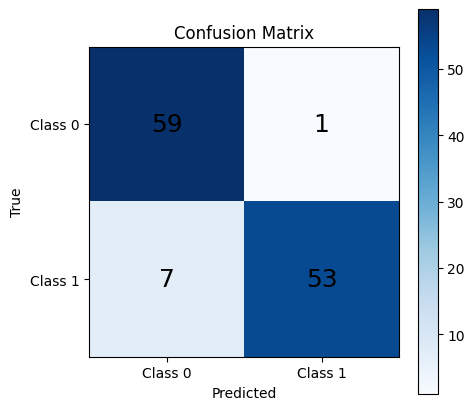

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

### Questions

Try and respond to these questions in a summarized manner.
1. What does a hidden layer do? A hidden layer plays a role of 
2. Why do we need activation functions?
3. What is the role of epochs?
4. What is the role of weights?
5. What happens if the network is too small?
6. What happens if the network is too large?

1. What does a hidden layer do?
   A hidden layer transforms raw input data into more useful representations, helping the network learn important patterns in the data.

2. Why do we need activation functions?
   Activation functions introduce non-linearity into the network. Without them, a neural network would behave like a single linear function regardless of the number of layers, making it unable to learn complex patterns.

3. What is the role of epochs?
   During each epoch, the model processes the entire dataset, makes predictions, calculates errors, and updates its weights to improve future predictions.

4. What is the role of weights?
   Weights determine how important each feature is to the prediction. They are adjusted during training to reduce errors and improve accuracy.

5. What happens if the network is too small?
   A small network may not have enough capacity to learn the underlying patterns in the data, leading to underfitting.

6. What happens if the network is too large?
   A very large network may memorize the training data instead of learning general patterns, which can cause overfitting.


## For more complex coded neural networks, check:

* https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html